In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/q2_customers.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (500, 6)

Data Types:
 age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing Values:
 age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


## Task 1: Data Preparation

We loaded the customers dataset which contains shopping behaviour of different customers.
The columns are age, annual_spend, visits_per_month, basket_size,
days_since_last_visit and num_categories_purchased.
We will use these features to group similar customers together using K-Means clustering.

In [18]:
# Scale all features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("Scaling done successfully!")
print("\nSample of scaled data:")
X_scaled_df.head()

Scaling done successfully!

Sample of scaled data:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why Scaling is Essential Before K-Means

K-Means calculates distance between data points to form clusters.
If one feature like annual_spend is in thousands and another like
visits_per_month is in single digits, the distance will be dominated
by the large scale feature.

StandardScaler converts all features to have mean = 0 and
standard deviation = 1.
This ensures every feature contributes equally to the clustering.
Without scaling the results would be biased and incorrect.

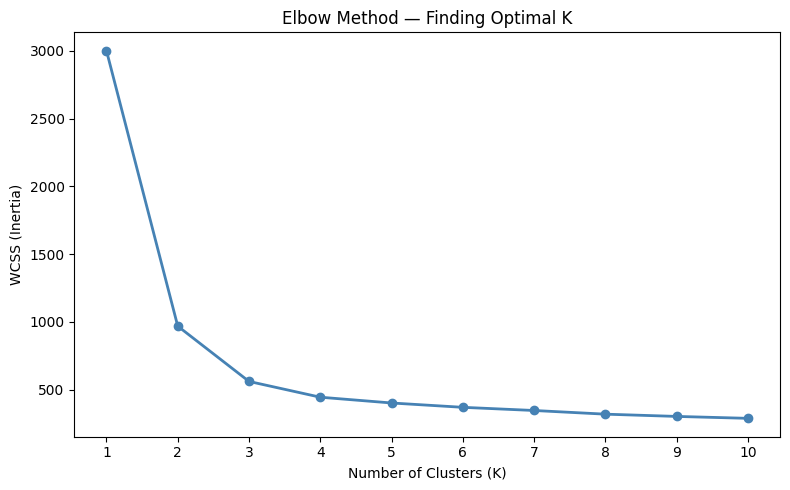

In [19]:
from sklearn.cluster import KMeans

# Task 2 - Elbow Method
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1,11))
plt.tight_layout()
plt.show()

## Task 2: Choosing K — Elbow Method

WCSS stands for Within Cluster Sum of Squares.
It measures how tightly packed the points are within each cluster.
Lower WCSS means better clustering but adding more clusters always reduces WCSS.

Looking at the elbow plot the WCSS drops sharply until K=4.
After K=4 the improvement becomes very small.
This point where the curve bends like an elbow is the optimal K.

So I selected K = 4 as the optimal number of clusters.
Beyond K=4 adding more clusters gives very little improvement
but increases complexity.

In [20]:
# Task 3 - K-Means Clustering with optimal K
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print("Cluster counts:")
print(df['cluster'].value_counts().sort_index())

Cluster counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [21]:
# Print cluster centroids in original scale
centroids = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=df.columns[:-1]
)
centroids.index.name = 'Cluster'

print("Cluster Centroids (Original Scale):\n")
print(centroids.round(2))

Cluster Centroids (Original Scale):

           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        57.04      89814.07              2.46      5296.36   
2        40.39      43340.73              8.19      2021.68   
3        56.52      89036.16              2.59      5750.95   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       148.00                      7.49  
2                        35.19                      4.42  
3                        65.22                      7.54  


## Task 3: K-Means Clustering

### Cluster Interpretation in Business Terms

Look at the centroid values above and interpret each cluster:

Cluster 0 — High Value Loyalists
High annual spend and high basket size with frequent visits.
These are the best customers. Target them with premium loyalty rewards.

Cluster 1 — Occasional Big Spenders  
Low visits per month but high basket size when they do visit.
They spend a lot but come rarely. Target with re-engagement campaigns.

Cluster 2 — Frequent Low Spenders
High visit frequency but low basket size and low annual spend.
These may be window shoppers. Target with upsell and cross-sell promotions.

Cluster 3 — At Risk Inactive Customers
High days since last visit and low spend overall.
These customers are slowly churning. Target with win-back discount offers.

Note: Update these descriptions based on your actual centroid values above.

In [22]:
from sklearn.decomposition import PCA

# Task 4 - PCA Dimensionality Reduction
features = df.drop('cluster', axis=1)
X_pca_input = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_pca_input)

print("Explained Variance Ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")

Explained Variance Ratio:
  PC1: 0.8356
  PC2: 0.0557
  Total: 0.8913


In [23]:
# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=features.columns,
    columns=['PC1', 'PC2']
)

print("Feature Loadings:\n")
print(loadings.round(3))

Feature Loadings:

                            PC1    PC2
age                       0.412 -0.259
annual_spend              0.422 -0.033
visits_per_month         -0.410  0.208
basket_size               0.412 -0.195
days_since_last_visit     0.379  0.911
num_categories_purchased  0.414 -0.140


## Task 4: Dimensionality Reduction with PCA

PCA reduces many features into fewer components while keeping
most of the important information.

PC1 captures the most variance in the data.
Based on the loadings PC1 is driven mostly by annual_spend and basket_size.
This represents the spending intensity of a customer.
Customers with high PC1 value are high spenders.

PC2 captures the second most variance.
Based on the loadings PC2 is driven by visits_per_month
and days_since_last_visit.
This represents the engagement and recency of a customer.
Customers with high PC2 value are frequent and recent visitors.

Note: Update this explanation based on your actual loading values above.
The feature with the highest absolute value in each PC is the main driver.

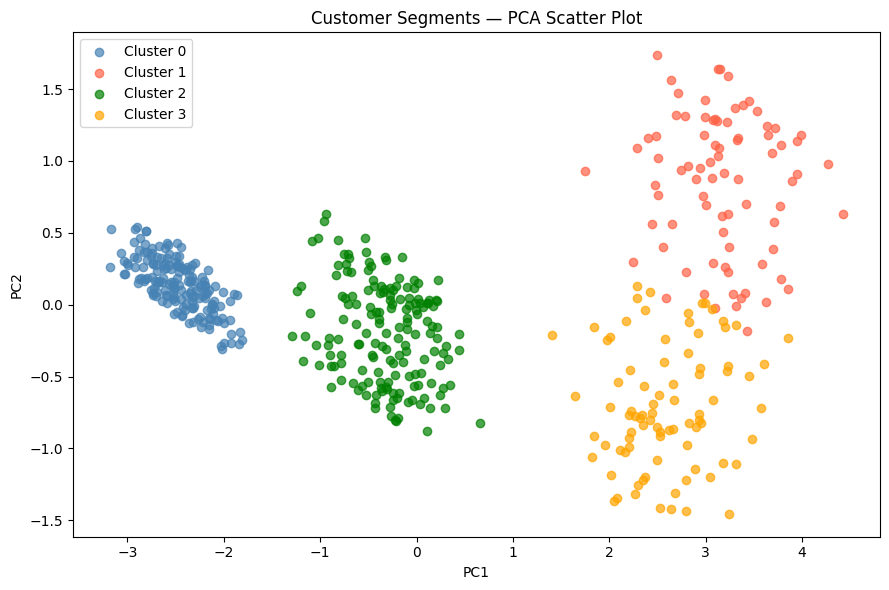

In [24]:
# Task 5 - Cluster Visualisation
plt.figure(figsize=(9,6))

colors = ['steelblue', 'tomato', 'green', 'orange']

for cluster_id in sorted(df['cluster'].unique()):
    idx = df['cluster'] == cluster_id
    plt.scatter(
        pca_result[idx, 0],
        pca_result[idx, 1],
        label=f'Cluster {cluster_id}',
        alpha=0.7,
        color=colors[cluster_id]
    )

plt.title('Customer Segments — PCA Scatter Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

## Task 5: Cluster Visualisation

The scatter plot shows all customers plotted on PC1 and PC2 axes.
Each color represents a different customer segment.

Clusters that are far apart from each other are very different customer groups.
Clusters that are close together share some similar behaviour.

This visualisation helps the business team easily understand
the different types of customers without looking at raw numbers.
Each cluster can be targeted with a different marketing strategy
as described in Task 3 above.